In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
from pathlib import Path
import logging

import matplotlib.pyplot as plt

import lsstypes as types

from clustering_statistics.tools import _read_catalog, write_stats, select_region#, reshuffle_randoms
from astropy.constants import c

code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
from tools import reshuffle_randoms, setup_logging

# disable jax warning:
# logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# setup_logging(level=logging.INFO)

# Add zsmear to mocks

In [3]:
# gather directories
dv_dir   = Path("/pscratch/sd/h/hanyuz/desi-dr2-hod/QSO/QSO_fit_dv/")
desi_dir = Path("/global/cfs/projectdirs/desi/mocks/cai/")
print(desi_dir)
#
imocks = np.arange(25)
# imocks = [i for i in np.arange(9)] + [i for i in np.arange(10,25)]
# print(imocks)
regions = ['NGC','SGC']
nran = 4
# _type = 'combined'
_type = 'single'

zmin, zmax = 0.8, 2.1
dv_file = np.loadtxt(dv_dir / f"dv_lorentzian_z{zmin}_{zmax}.dat")

/global/cfs/projectdirs/desi/mocks/cai


In [4]:
%%time

for imock in imocks:
    print(f"working on mock{imock}")
    start = 0
    base_dir = desi_dir / f"abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph{imock:03d}/CutSky/QSO_lorentzian/{_type}/abacus_HFv2/mock{imock:d}"
    for i, region in enumerate(regions):
        # read catalog
        fn = base_dir / f"QSO_complete_{region}_clustering.dat.h5"
        data = _read_catalog(fn)
    
        print(data.size, start, start+data.size)
        dv = dv_file[np.arange(start, start+data.size)] # different regions draw different dv
        start += data.size
        
        # apply redshift error to existing redshift column
        CSPEED = c.to_value('km/s')
        data['Z'] = data['Z'] + dv/CSPEED*(1+data['Z'])
        print(data.size, data['Z'].min(), data['Z'].max())
    
        # apply some redshift bound
        zmin_bound, zmax_bound = 0. <= data['Z'], data['Z'] <= 10. # cap zmin to be non-negative
        out_of_zlim  = ~((zmin <= data['Z']) & (data['Z'] <= zmax))
        print(f"out of zlim {out_of_zlim.sum() / data.size * 100:.2f}%")
        data['Z'][~zmin_bound] = 0
        # data['Z'][~zmax_bound] = zmax
        print(data.size, data['Z'].min(), data['Z'].max())
        
        # save new catalog
        cat_dir = Path(os.getenv('SCRATCH')) / f"mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph{imock:03d}/CutSky/QSO_lorentzian/{_type}/abacus_HFv2/mock{imock:d}/zsmear/"
        output_fn = cat_dir / f"QSO_complete_{region}_clustering.dat.h5"
        write_stats(output_fn, data)
        print(output_fn)
    
        print()

working on mock0
1679080 0 1679080
1679080 -1.0791525419774404 5.053736395108925
out of zlim 0.36%
1679080 0.0 5.053736395108925
/pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/zsmear/QSO_complete_NGC_clustering.dat.h5

851345 1679080 2530425
851345 -1.0101022717833414 4.90117264357354
out of zlim 0.35%
851345 0.0 4.90117264357354
/pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/zsmear/QSO_complete_SGC_clustering.dat.h5

working on mock1
1682941 0 1682941
1682941 -1.0788266603392915 5.0156285631449995
out of zlim 0.36%
1682941 0.0 5.0156285631449995
/pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph001/CutSky/QSO_lorentzian/single/abacus_HFv2/mock1/zsmear/QSO_complete_NGC_clustering.dat.h5

849382 1682941 2532323
849382 -1.0101786621817852 4.9156336045274305
out of zlim 0.35%
849382 0.0 4.91

In [5]:
%%time
# now reassign redshifts to randoms by sampling them from the new mock data catalogs
for imock in imocks:
    # load new mock data catalog once
    base_dir = desi_dir / f"abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph{imock:03d}/CutSky/QSO_lorentzian/{_type}/abacus_HFv2/mock{imock:d}"
    cat_dir  = Path(os.getenv('SCRATCH')) / f"mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph{imock:03d}/CutSky/QSO_lorentzian/{_type}/abacus_HFv2/mock{imock:d}/zsmear/"
    fns = [cat_dir / f"QSO_complete_{region}_clustering.dat.h5" for region in ['NGC','SGC']]
    merged_data = _read_catalog(fns) # must load both NGC and SGC
    
    for inran in range(nran):
        print(f"working on mock{imock}, randoms {inran+1}/{nran}")
        print(inran)
        # load randoms
        rands_fn = [base_dir / f"QSO_complete_{region}_{inran}_clustering.ran.h5" for region in ['NGC','SGC']] 
        print(rands_fn)
        randoms = _read_catalog(rands_fn)
        # print(randoms)

        seed = 100 * imock + inran
        resampled_randoms = reshuffle_randoms(randoms, merged_data, merged_data, 'QSO', seed=seed, ignore_ftile=True)
        # print(resampled_randoms)
        
        for ireg in regions:
            print(ireg)
            randoms = resampled_randoms[select_region(resampled_randoms['RA'], resampled_randoms['DEC'], region=ireg)]
            print(randoms)
            # save expanded randoms catalog
            output_fn =  cat_dir / f"QSO_complete_{ireg}_{inran}_clustering.ran.h5"
            write_stats(output_fn, randoms)
            print('saved', output_fn)
            print()
    
        print()

working on mock0, randoms 1/4
0
[PosixPath('/global/cfs/projectdirs/desi/mocks/cai/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/QSO_complete_NGC_0_clustering.ran.h5'), PosixPath('/global/cfs/projectdirs/desi/mocks/cai/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/QSO_complete_SGC_0_clustering.ran.h5')]


/global/homes/a/arosado/cai-dr2-clustering-products/clustering_statistics/tools.py:2800: RuntimeWarning: invalid value encountered in divide
  nz = np.where(nz_now > 0, nz / nz_now, 0.)
/global/homes/a/arosado/cai-dr2-clustering-products/clustering_statistics/tools.py:2820: UserWarning: FRAC_TLOBS_TILES not in randoms, but it isn't trivially one in the data; the reshuffled randoms will most likely not match the data
  warnings.warn(f"{column} not in randoms, but it isn't trivially one in the data; the reshuffled randoms will most likely not match the data")


NGC
Catalog(csize=18543963, size=18543963, columns=['DEC', 'NTILE', 'NX', 'PHOTSYS', 'RA', 'TARGETID', 'TARGETID_DATA', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_FKP', 'WEIGHT_SYS', 'WEIGHT_ZFAIL', 'Z'])
saved /pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/zsmear/QSO_complete_NGC_0_clustering.ran.h5

SGC
Catalog(csize=9386696, size=9386696, columns=['DEC', 'NTILE', 'NX', 'PHOTSYS', 'RA', 'TARGETID', 'TARGETID_DATA', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_FKP', 'WEIGHT_SYS', 'WEIGHT_ZFAIL', 'Z'])
saved /pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/zsmear/QSO_complete_SGC_0_clustering.ran.h5


working on mock0, randoms 2/4
1
[PosixPath('/global/cfs/projectdirs/desi/mocks/cai/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/QSO_complete_NGC_1_clustering.ran.h5'), PosixPath('/global/cfs/proj

/global/homes/a/arosado/cai-dr2-clustering-products/clustering_statistics/tools.py:2800: RuntimeWarning: invalid value encountered in divide
  nz = np.where(nz_now > 0, nz / nz_now, 0.)
/global/homes/a/arosado/cai-dr2-clustering-products/clustering_statistics/tools.py:2820: UserWarning: FRAC_TLOBS_TILES not in randoms, but it isn't trivially one in the data; the reshuffled randoms will most likely not match the data
  warnings.warn(f"{column} not in randoms, but it isn't trivially one in the data; the reshuffled randoms will most likely not match the data")


NGC
Catalog(csize=18542945, size=18542945, columns=['DEC', 'NTILE', 'NX', 'PHOTSYS', 'RA', 'TARGETID', 'TARGETID_DATA', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_FKP', 'WEIGHT_SYS', 'WEIGHT_ZFAIL', 'Z'])
saved /pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/zsmear/QSO_complete_NGC_1_clustering.ran.h5

SGC
Catalog(csize=9388184, size=9388184, columns=['DEC', 'NTILE', 'NX', 'PHOTSYS', 'RA', 'TARGETID', 'TARGETID_DATA', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_FKP', 'WEIGHT_SYS', 'WEIGHT_ZFAIL', 'Z'])
saved /pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/zsmear/QSO_complete_SGC_1_clustering.ran.h5


working on mock0, randoms 3/4
2
[PosixPath('/global/cfs/projectdirs/desi/mocks/cai/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/single/abacus_HFv2/mock0/QSO_complete_NGC_2_clustering.ran.h5'), PosixPath('/global/cfs/proj

In [3]:
# !ls /pscratch/sd/a/arosado/mockchallenge/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/combined/abacus_HFv2/mock0/zsmear/

In [2]:
# kws = dict(range=(0.8,2.1),bins=25, histtype='step', density=True)
# plt.hist(data['Z_VSMEAR'],**kws)
# plt.hist(data['Z'],**kws)
# plt.show()

In [4]:
# !ls /global/cfs/projectdirs/desi/mocks/cai/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph000/CutSky/QSO_lorentzian/combined/abacus_HFv2/mock0/

In [5]:
# !ls /global/cfs/projectdirs/desi/mocks/cai/abacus_HF/DR2_v2.0/AbacusSummit_base_c000_ph011/CutSky/QSO_lorentzian/single/abacus_HFv2/mock11/

# Plots

In [9]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

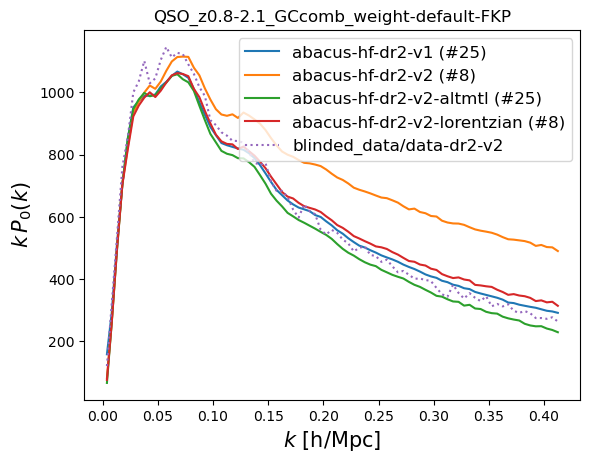

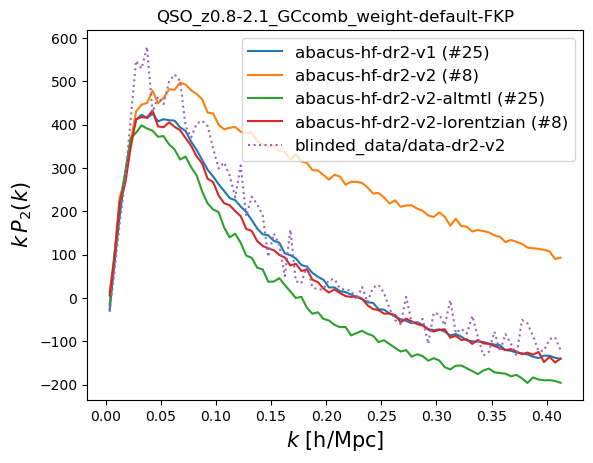

In [10]:
base = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v1/')
stats = [types.read(base / f'mock{imock}/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default.h5') for imock in np.arange(25)] 
nmocks_v1 = len(stats)
mean_v1  = types.mean(stats).select(k=slice(0, None, 5)) 

base = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/')
# stats = [types.read(base / f'mock{imock}/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5') for imock in np.arange(25)] 
stats = [types.read(base / f'mock{imock}/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5') for imock in np.arange(25)] 
nmocks_v2_altmtl = len(stats)
mean_v2_altmtl  = types.mean(stats).select(k=slice(0, None, 5)) 

base = Path('/pscratch/sd/a/arosado/cai-dr2-benchmarks/full_shape/base/abacus-hf-dr2-v2/')
stats = [types.read(base / f'mock{imock}/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5') for imock in [i for i in range(5)]+[10,11,12]]
# stats = [types.read(base / f'mock{imock}/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5') for imock in np.arange(25)]
nmocks_v2 = len(stats)
mean_v2  = types.mean(stats).select(k=slice(0, None, 5)) 

base = Path('/pscratch/sd/a/arosado/cai-dr2-benchmarks/full_shape/base/abacus-hf-dr2-v2-lorentzian/')
stats = [types.read(base / f'mock{imock}/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5') for imock in [i for i in range(5)]+[10,11,12]] 
nmocks_v2_lor = len(stats)
mean_v2_lor  = types.mean(stats).select(k=slice(0, None, 5)) 

base = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/data_splits/blinded_data/data-dr2-v2/')
blinded_data = types.read(base / f'mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5').select(k=slice(0, None, 5)) 

base = Path('/pscratch/sd/a/arosado/cai-dr2-benchmarks/protected/base/data-dr2-v2/mock0/')
protected_data = types.read(base / f'mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5').select(k=slice(0, None, 5)) 

ells = mean_v2.ells[:2]
for kexp in [1]:
    for i, ell in enumerate(ells):
        pole = mean_v1.get(ell)
        shot = pole.values('num_shotnoise') / pole.values('norm')
        k = pole.coords('k')
        # print(k)
        value = k**kexp * (pole.value() - shot)
        # print(value)
        plt.plot(k,value,color="C0",ls='-')
        
        pole = mean_v2.get(ell)
        k = pole.coords('k')
        value = k**kexp * pole.value()
        # print(value)
        plt.plot(k,value,color="C1",ls='-')
        
        pole = mean_v2_altmtl.get(ell)
        k = pole.coords('k')
        value = k**kexp * pole.value()
        # print(value)
        plt.plot(k,value,color="C2",ls='-')
        
        pole = mean_v2_lor.get(ell)
        k = pole.coords('k')
        value = k**kexp * pole.value()
        # print(value)
        plt.plot(k,value,color="C3",ls='-')

        pole = blinded_data.get(ell)
        k = pole.coords('k')
        value = k**kexp * pole.value()
        # print(value)
        plt.plot(k,value,color="C4",ls=':')

        if i==5:
            pole = protected_data.get(ell)
            k = pole.coords('k')
            value = k**kexp * pole.value()
            # print(value)
            plt.plot(k,value,color="C5",ls=':')
        
        plt.plot([],[],color="C0",ls='-',label=f'abacus-hf-dr2-v1 (#{nmocks_v1})')
        plt.plot([],[],color="C1",ls='-',label=f'abacus-hf-dr2-v2 (#{nmocks_v2})')
        plt.plot([],[],color="C2",ls='-',label=f'abacus-hf-dr2-v2-altmtl (#{nmocks_v2_altmtl})')
        plt.plot([],[],color="C3",ls='-',label=f'abacus-hf-dr2-v2-lorentzian (#{nmocks_v2_lor})')
        plt.plot([],[],color="C4",ls=':',label='blinded_data/data-dr2-v2')
        if i==5:plt.plot([],[],color="C5",ls=':',label='protected_data/data-dr2-v2')
        
        if kexp == 0:
            ax = plt.gca()
            ax.set_yscale('log')
            ax.set_xscale('log')
       
        plt.title('QSO_z0.8-2.1_GCcomb_weight-default-FKP')
        plt.legend(fontsize=12)#,loc='lower left',ncols=2)
        plt.ylabel(rf'$k\,P_{ell}(k)$',fontsize=15)
        plt.xlabel(r'$k$ [h/Mpc]',fontsize=15)
        plt.savefig(plot_dir / f'test_zsmear_qso_lorentzian_ell{ell}.{ext}',bbox_inches='tight', pad_inches=0.1, dpi=200)
        plt.show()